In [1]:
import numpy as np
from matplotlib import pyplot as plt
from plt_func import plt_hs

(100, 512)
Num of time cells: 196
Interval length (s): 4.5


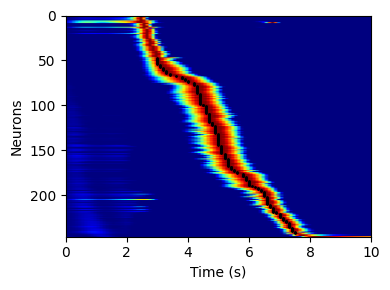

In [2]:
trial = 0
load_data_type = f'2TS_vary{trial}'
num_neuron = 512

data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
hidden_states = data[f'hidden_states_{num_neuron}']
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

T = avg_hs.shape[0]
if trial == 0:
    time_start, time_end = int(T * 0.3),  int(T * 0.75)
elif trial == 1:
    time_start, time_end = int(T * 0.3),  int(T * 0.7)
elif trial == 2:
    time_start, time_end = int(T * 0.35), int(T * 0.65)
elif trial == 3:
    time_start, time_end = int(T * 0.4),  int(T * 0.6)
elif trial == 4:
    time_start, time_end = int(T * 0.45), int(T * 0.55)
else:
    raise ValueError('Invalid trial number. Must be between 0 and 4.')

# Plot the average hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, time_start=time_start, time_end=time_end)
plt.tight_layout()
plt.xlabel('Time (s)')

# Get each neuron's max firing time
max_time_pts = np.argmax(norm_hs, axis=0)  

# Calculate the number of neurons with max firing time within the interval
num_in_interval = np.sum((max_time_pts >= time_start) & (max_time_pts <= time_end))
print('Num of time cells:', num_in_interval)
print('Interval length (s):', (time_end - time_start)/10)

In [3]:
num_time_cells = [196, 191, 171, 80, 45]
intervals = [4.5, 4.0, 3.0, 2.0, 0.6]

In [4]:
# Do a linear fit
def linear(x, m, b):
    return m * x + b
from scipy.optimize import curve_fit
popt, pcov = curve_fit(linear, intervals, num_time_cells)
x_fit = np.linspace(0, 5, 100)
y_fit = linear(x_fit, *popt)

# # Calculate the correlation coefficient using seaborn
# import seaborn as sns
# fig, ax = plt.subplots(figsize=(4, 3.5))

# correlation_matrix = np.corrcoef(intervals, num_time_cells)
# correlation_coefficient = correlation_matrix[0, 1]
# print(f'Correlation coefficient: {correlation_coefficient:.2f}')
# sns.regplot(x=intervals, y=num_time_cells, ci=95, scatter=False, 
#             line_kws={"color": 'steelblue', "label":f'corr={correlation_coefficient:.2f}'},
#             label=r'corr={:.2f}'.format(correlation_coefficient))

# # Plot num_time_cells vs intervals

# # plt.plot(x_fit, y_fit, color='#297270')
# ax.scatter(intervals, num_time_cells, marker='o', color='black')
# ax.set_xlabel('Interval (s)')
# ax.set_ylabel('Number of Time Cells')
# plt.legend()
# plt.tight_layout()

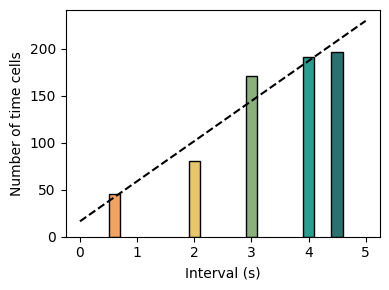

In [5]:
colours = ['#297270', '#299D8F', '#8AB07C',  '#E7C66B', '#F3A361']
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(intervals, num_time_cells, color=colours, width=0.2, edgecolor='black')
# # Plot a linear fit in dashed line
ax.plot(x_fit, y_fit, color='black', linestyle='--', label='Linear fit')
ax.set_xlabel('Interval (s)')
ax.set_ylabel('Number of time cells')
plt.tight_layout()
plt.savefig('fig4_time_cell_corr_time_interval.png', transparent=False, dpi=500)